In [3]:
!pip install statsforecast mlforecast textblob neuralforecast plotly
!pip install holidays
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS

# Configuração de estilo para os gráficos 
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Ambiente configurado com sucesso!")

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


C:\Users\Utilizador\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ambiente configurado com sucesso!


## 1. Extração dos Dados

In [4]:
# EXTRAÇÃO DE DADOS
import pandas as pd
import requests
import numpy as np

def extract_data_atendimentos_nos_csp_gripe(ars, start_date, end_date, cols=['no_consultas_gripe_nos_csp']):
    """
    Extracts data from the 'Atendimentos nos CSP - Gripe' dataset
    hosted at the SNS Transparency Portal.
    """
    indicator = "atendimentos-nos-csp-gripe"
    base_url = f"https://transparencia.sns.gov.pt/api/explore/v2.1/catalog/datasets/{indicator}/records"

    limit = 100
    df_data = pd.DataFrame()

    date_ranges = pd.date_range(start=start_date, end=end_date, freq=f"{limit}D", inclusive="left")

    print(f"   -> A extrair dados em {len(date_ranges)} lotes")
    
    for i, s_date in enumerate(date_ranges):
        s_date_str = s_date.strftime("%Y-%m-%d")
        e_date_str = (date_ranges[i + 1] - pd.Timedelta("1D")).strftime("%Y-%m-%d") if i < len(date_ranges) - 1 else end_date

        params = {
            "where": f"ars=\"ARS {ars}\" AND dia>=\"{s_date_str}\" AND dia<=\"{e_date_str}\"",
            "limit": limit
        }

        try:
            response = requests.get(base_url, params=params)
            response.raise_for_status()

            data_extract = response.json()
            df_aux = pd.json_normalize(data_extract.get("results", []))

            if not df_aux.empty:
                df_data = pd.concat([df_data, df_aux], ignore_index=True)
        except Exception as e:
            print(f"Erro no lote {s_date_str}: {e}")

    if not df_data.empty:
        df_data = df_data.astype(int, errors="ignore").sort_values("dia").reset_index(drop=True)
        df_data["dia"] = pd.to_datetime(df_data["dia"], errors="coerce")
        df_data = df_data.filter(["dia"] + cols)

    return df_data

# EXECUÇÃO E PREPARAÇÃO DO TRABALHO

# Definir parâmetros
ARS_ALVO = "Norte"
DATA_INICIO_EXTRACAO = "2016-11-01"
DATA_HOJE = pd.Timestamp.now().strftime("%Y-%m-%d") # Vamos até hoje para calcular o GAP real

# Chamar a função
print(f"A extrair dados para ARS {ARS_ALVO} ({DATA_INICIO_EXTRACAO} a {DATA_HOJE})...")
df_raw = extract_data_atendimentos_nos_csp_gripe(ARS_ALVO, DATA_INICIO_EXTRACAO, DATA_HOJE)

if df_raw.empty:
    raise ValueError("Erro: A extração não retornou dados. Verifica a internet ou o nome da ARS.")

# 3. ANÁLISE DO GAP 
ultima_data_real = df_raw['dia'].max()
hoje_real = pd.Timestamp.now().normalize()
atraso_dias = (hoje_real - ultima_data_real).days

# Simular a visão do dia 3 de Dezembro 
data_objetivo_prof = pd.to_datetime('2025-12-03')
ultimo_dado_visivel = data_objetivo_prof - pd.Timedelta(days=atraso_dias)

print(f"\n ANÁLISE DO GAP ")
print(f"   Hoje é: {hoje_real.date()}")
print(f"   Último dado no SNS: {ultima_data_real.date()}")
print(f"   Atraso Real (GAP): {atraso_dias} dias")
print(f"   (No dia 3 de Dez, só veríamos dados até dia {ultimo_dado_visivel.day})")

# 4. PREPARAÇÃO FINAL (FORMATO NIXTLA)
print("\n3. A formatar dados para o modelo...")

# Renomear para o padrão ds/y
df_trabalho = df_raw.rename(columns={'dia': 'ds', 'no_consultas_gripe_nos_csp': 'y'})

# Filtrar até 31/12/2025 
df_trabalho = df_trabalho[df_trabalho['ds'] <= '2025-12-31'].copy()

# Garantir continuidade diária 
df_trabalho = df_trabalho.set_index('ds')
idx_completo = pd.date_range(start=DATA_INICIO_EXTRACAO, end='2025-12-31', freq='D')
df_trabalho = df_trabalho.reindex(idx_completo)

dias_falta = df_trabalho['y'].isna().sum()
if dias_falta > 0:
    print(f"   Detetados {dias_falta} dias em falta. A interpolar linearmente...")
    df_trabalho['y'] = df_trabalho['y'].interpolate(method='linear')

df_trabalho = df_trabalho.reset_index().rename(columns={'index': 'ds'})
df_trabalho['unique_id'] = 'Norte'

print(f" 'df_trabalho' pronto com {len(df_trabalho)} linhas.")
print(df_trabalho.tail())

A extrair dados para ARS Norte (2016-11-01 a 2026-01-18)...
   -> A extrair dados em 34 lotes

 ANÁLISE DO GAP 
   Hoje é: 2026-01-18
   Último dado no SNS: 2026-01-16
   Atraso Real (GAP): 2 dias
   (No dia 3 de Dez, só veríamos dados até dia 1)

3. A formatar dados para o modelo...
 'df_trabalho' pronto com 3348 linhas.
             ds    y unique_id
3343 2025-12-27  192     Norte
3344 2025-12-28  139     Norte
3345 2025-12-29  592     Norte
3346 2025-12-30  552     Norte
3347 2025-12-31  137     Norte


## 2. Análise Exploratória

### 2.1 Apresentação da Série

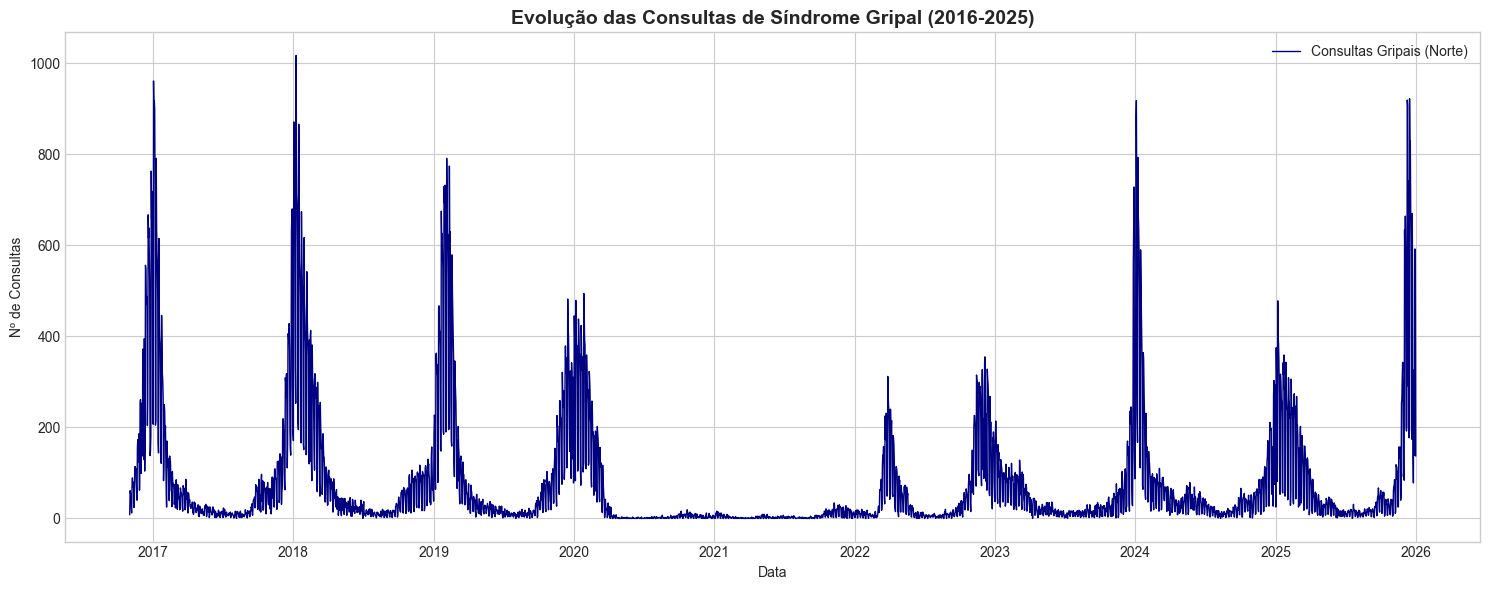

In [44]:
import matplotlib.pyplot as plt

# Gráfico 1: Série Completa (2016-2025)
plt.figure(figsize=(15, 6))
plt.plot(df_trabalho['ds'], df_trabalho['y'], label='Consultas Gripais (Norte)', color='navy', linewidth=1)
plt.title("Evolução das Consultas de Síndrome Gripal (2016-2025)", fontsize=14, fontweight='bold')
plt.ylabel("Nº de Consultas")
plt.xlabel("Data")
plt.legend()
plt.tight_layout()
plt.show()


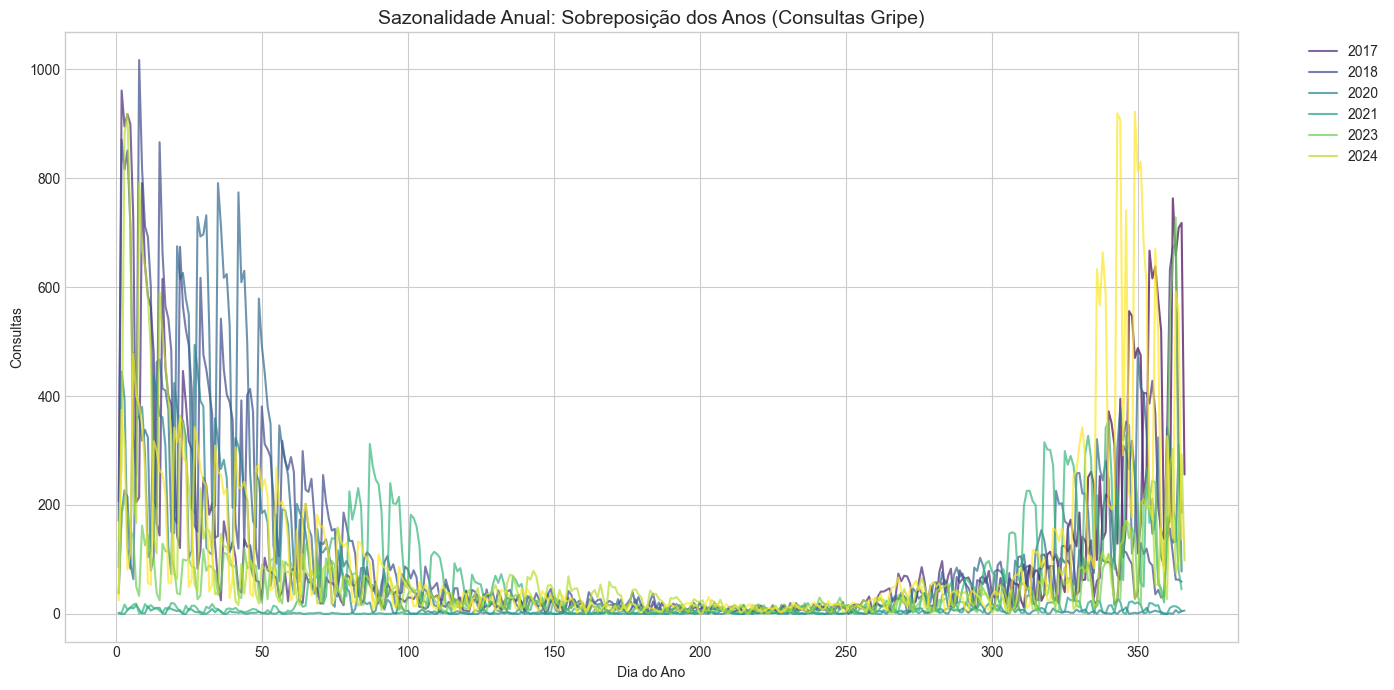

In [45]:
import seaborn as sns

# Criar colunas auxiliares
df_eda = df_trabalho.copy()
df_eda['Ano'] = df_eda['ds'].dt.year
df_eda['Mes'] = df_eda['ds'].dt.month
df_eda['Dia_Ano'] = df_eda['ds'].dt.dayofyear

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_eda, x='Dia_Ano', y='y', hue='Ano', palette='viridis', alpha=0.7)
plt.title('Sazonalidade Anual: Sobreposição dos Anos (Consultas Gripe)', fontsize=14)
plt.xlabel('Dia do Ano')
plt.ylabel('Consultas')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2.2 Análise Exploratória dos Dados


ANÁLISE DO PERÍODO: 2024-09-01 a 2025-12-31


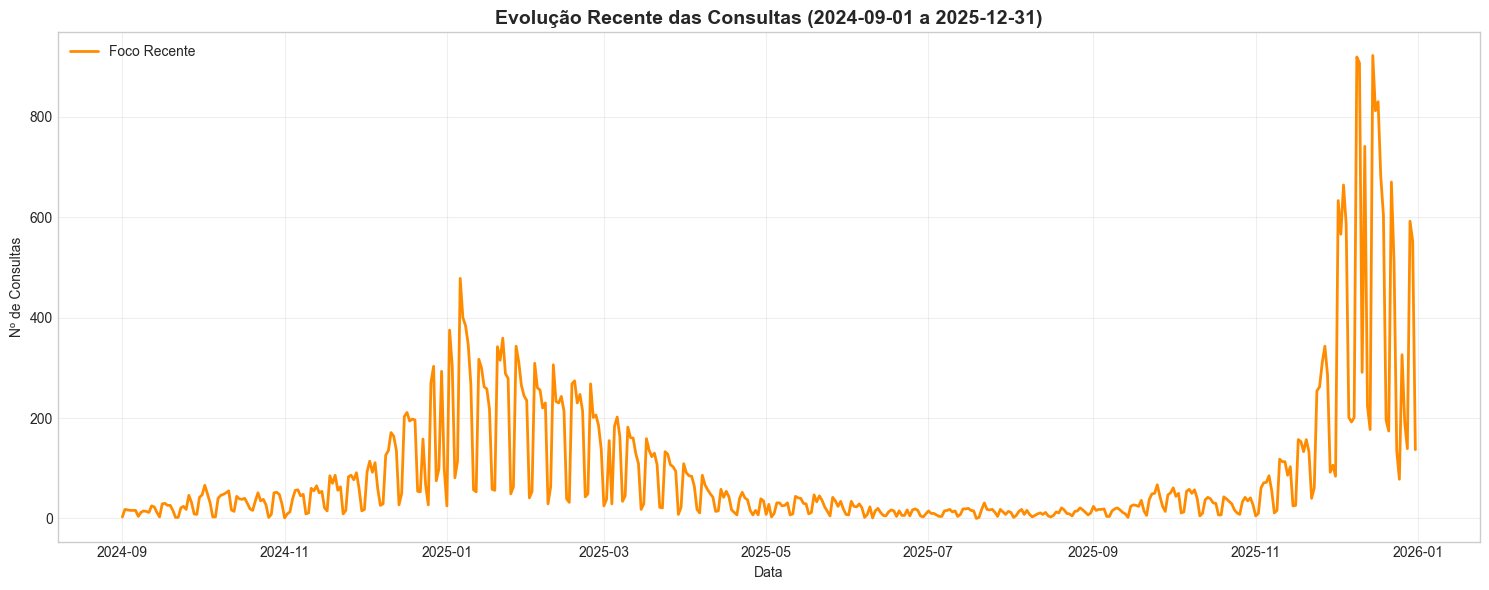

Investigação de Padrões Semanais:


C:\Users\Utilizador\AppData\Local\Temp\ipykernel_28660\2791837764.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dia_Semana', y='y', data=df_foco, order=ordem_dias, palette='viridis')


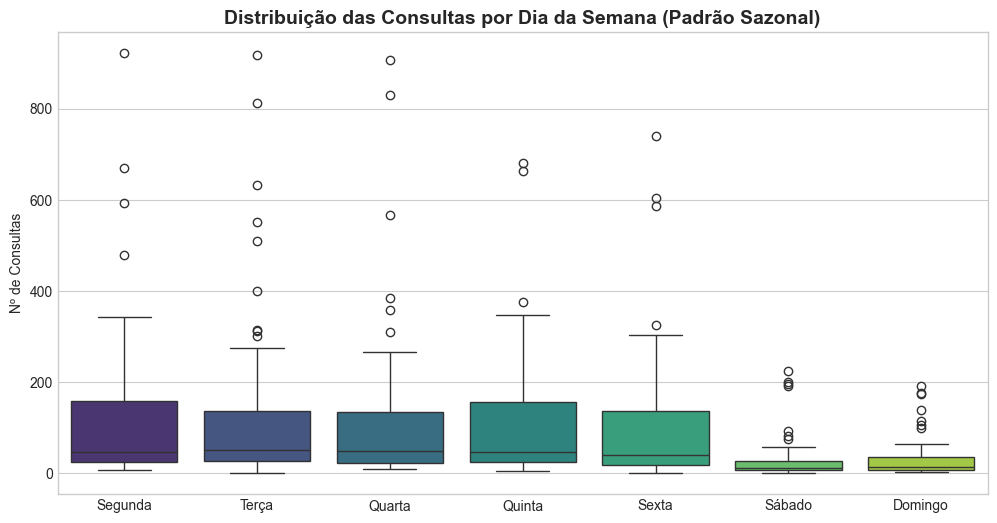

In [46]:
# Foco: Período de 2024-09-01 a 2025-10-31

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Criar o subset de dados para o foco (Set 2024 - Out 2025)
data_foco_inicio = '2024-09-01'
data_foco_fim = '2025-12-31'
df_foco = df_trabalho[(df_trabalho['ds'] >= data_foco_inicio) & (df_trabalho['ds'] <= data_foco_fim)].copy()

print(f"ANÁLISE DO PERÍODO: {data_foco_inicio} a {data_foco_fim}")

# GRÁFICO 2: Evolução Recente 
plt.figure(figsize=(15, 6))
plt.plot(df_foco['ds'], df_foco['y'], label='Foco Recente', color='darkorange', linewidth=2)
plt.title(f"Evolução Recente das Consultas ({data_foco_inicio} a {data_foco_fim})", fontsize=14, fontweight='bold')
plt.ylabel("Nº de Consultas")
plt.xlabel("Data")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ANÁLISE DE PADRÕES 
print("Investigação de Padrões Semanais:")
df_foco['Dia_Semana'] = df_foco['ds'].dt.day_name()
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
nomes_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

plt.figure(figsize=(12, 6))
sns.boxplot(x='Dia_Semana', y='y', data=df_foco, order=ordem_dias, palette='viridis')
plt.title('Distribuição das Consultas por Dia da Semana (Padrão Sazonal)', fontsize=14, fontweight='bold')
plt.ylabel('Nº de Consultas')
plt.xlabel('')
plt.xticks(ticks=range(7), labels=nomes_pt)
plt.show()


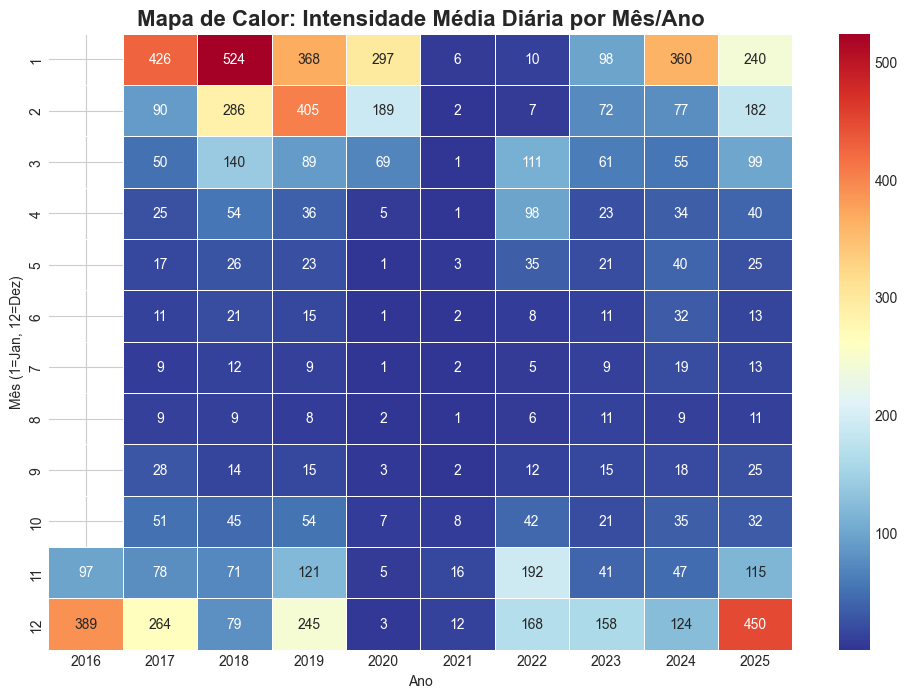

In [ ]:
# HEATMAP 
import seaborn as sns
import matplotlib.pyplot as plt

# Agrupar por Ano e Mês (Média de consultas diárias nesse mês)
df_heat = df_trabalho.copy()
df_heat['Ano'] = df_heat['ds'].dt.year
df_heat['Mes'] = df_heat['ds'].dt.month

pivot_table = df_heat.pivot_table(values='y', index='Mes', columns='Ano', aggfunc='mean')

# Plotar
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap='RdYlBu_r', annot=True, fmt='.0f', linewidths=.5)

plt.title('Mapa de Calor: Intensidade Média Diária por Mês/Ano', fontsize=16, fontweight='bold')
plt.ylabel('Mês (1=Jan, 12=Dez)')
plt.xlabel('Ano')
plt.show()

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_28660\3098829289.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_violin, x='Dia_Semana', y='y', order=ordem_dias, palette='viridis', inner="quartile")


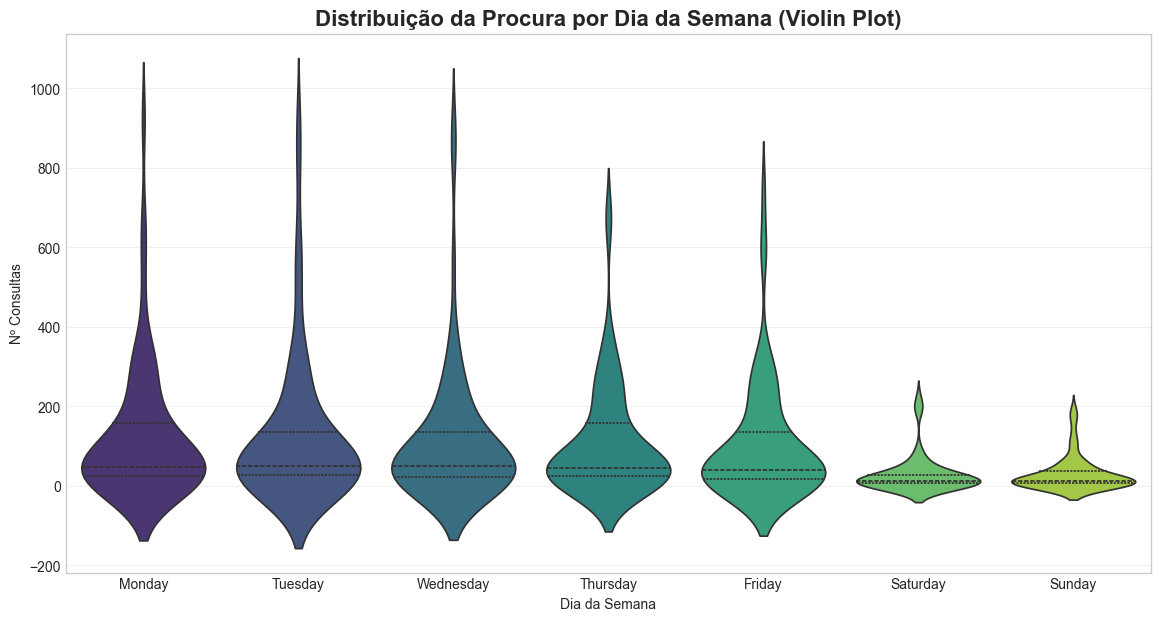

In [ ]:
# VIOLIN PLOT 
import seaborn as sns
import matplotlib.pyplot as plt

df_violin = df_trabalho.copy()
df_violin = df_violin[df_violin['ds'] >= '2024-09-01']

# Criar coluna com nomes dos dias
df_violin['Dia_Semana'] = df_violin['ds'].dt.day_name()
# Ordenar dias
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(14, 7))

sns.violinplot(data=df_violin, x='Dia_Semana', y='y', order=ordem_dias, palette='viridis', inner="quartile")

plt.title('Distribuição da Procura por Dia da Semana (Violin Plot)', fontsize=16, fontweight='bold')
plt.ylabel('Nº Consultas')
plt.xlabel('Dia da Semana')
plt.grid(True, axis='y', alpha=0.3)

plt.show()

### 2.3 Decomposição da Série Temporal

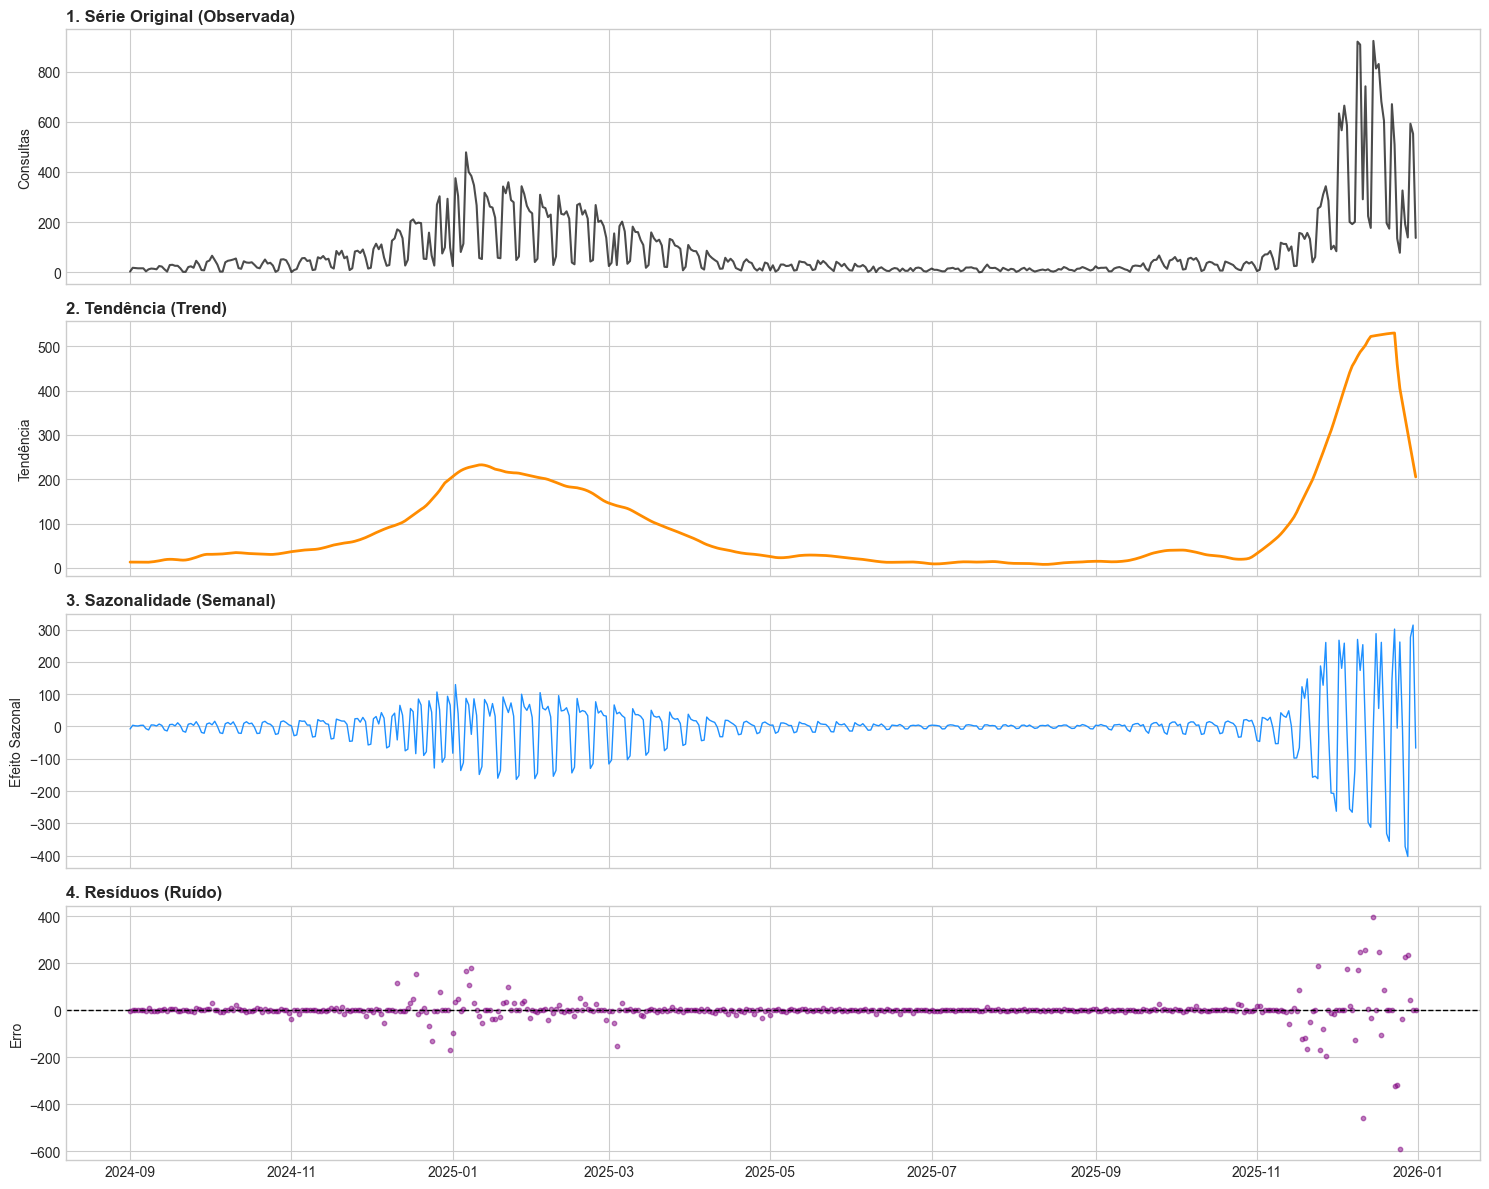

In [97]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import pandas as pd

# Filtrar o período 
mask_decomp = (df_trabalho['ds'] >= '2024-09-01') & (df_trabalho['ds'] <= '2025-12-31')
df_decomp = df_trabalho[mask_decomp].set_index('ds').copy()

# Aplicar STL (Seasonal-Trend decomposition using Loess)
stl = STL(df_decomp['y'], period=7, robust=True)
resultado = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# Original
axes[0].plot(df_decomp.index, df_decomp['y'], color='black', alpha=0.7)
axes[0].set_title('1. Série Original (Observada)', fontsize=12, fontweight='bold', loc='left')
axes[0].set_ylabel('Consultas')

# Tendência 
axes[1].plot(df_decomp.index, resultado.trend, color='#FF8C00', linewidth=2) 
axes[1].set_title('2. Tendência (Trend)', fontsize=12, fontweight='bold', loc='left')
axes[1].set_ylabel('Tendência')

# Sazonalidade 
axes[2].plot(df_decomp.index, resultado.seasonal, color='#1E90FF', linewidth=1) 
axes[2].set_title('3. Sazonalidade (Semanal)', fontsize=12, fontweight='bold', loc='left')
axes[2].set_ylabel('Efeito Sazonal')

# Resíduos 
axes[3].scatter(df_decomp.index, resultado.resid, color='#800080', s=10, alpha=0.5) 
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
axes[3].set_title('4. Resíduos (Ruído)', fontsize=12, fontweight='bold', loc='left')
axes[3].set_ylabel('Erro')

plt.tight_layout()
plt.show()

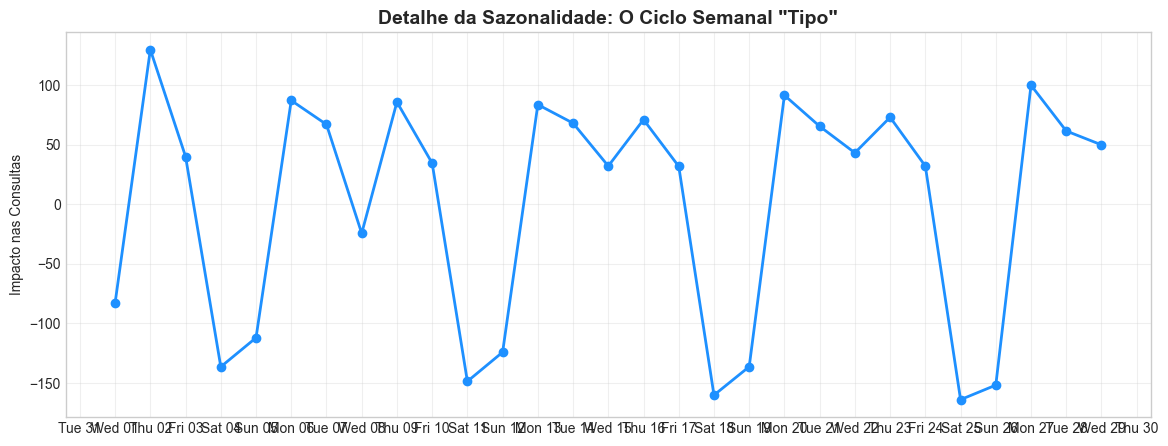

In [98]:
import matplotlib.dates as mdates

# Vamos pegar apenas nas primeiras 4 semanas de Janeiro 2025 para ver o padrão
data_zoom_ini = '2025-01-01'
data_zoom_fim = '2025-01-29'

# Extrair a componente sazonal calculada anteriormente
seasonal_component = resultado.seasonal
zoom_seasonal = seasonal_component[data_zoom_ini:data_zoom_fim]

plt.figure(figsize=(14, 5))

plt.plot(zoom_seasonal.index, zoom_seasonal.values, marker='o', color='#1E90FF', linewidth=2)

# Formatação
plt.title('Detalhe da Sazonalidade: O Ciclo Semanal "Tipo"', fontsize=14, fontweight='bold')
plt.ylabel('Impacto nas Consultas')
plt.grid(True, alpha=0.3)

# Mostrar os dias da semana no eixo X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))

plt.show()

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_28660\124841558.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Dia_Semana', y='y', data=df_foco, order=ordem_dias, palette='viridis', ax=axes[0], errorbar=None)
C:\Users\Utilizador\AppData\Local\Temp\ipykernel_28660\124841558.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(nomes_pt)
C:\Users\Utilizador\AppData\Local\Temp\ipykernel_28660\124841558.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dia_Semana', y='y', data=df_foco, order=ordem_dias, palette='viridis', ax=axes[1])
C:\Users\Utilizador\AppData\Local\Temp\

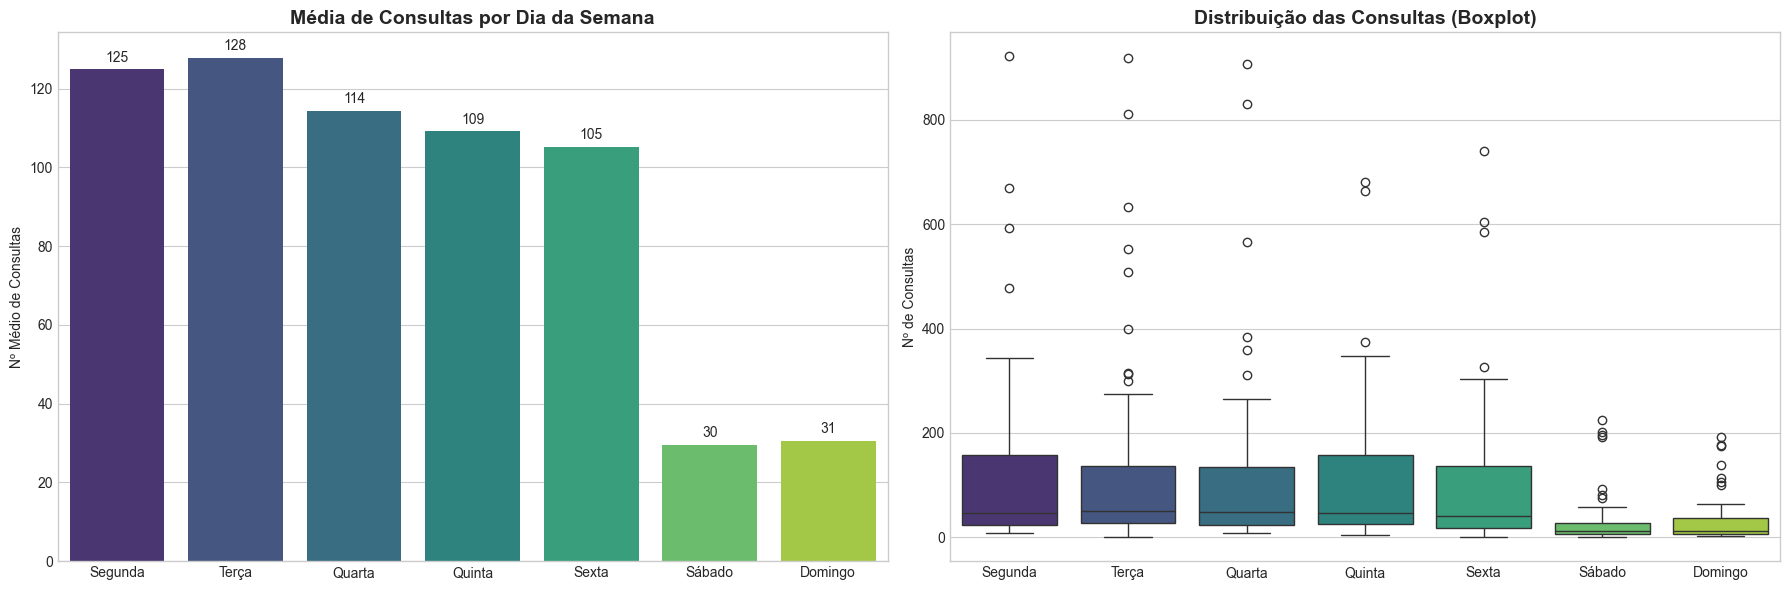

In [99]:
import seaborn as sns

# Criar colunas auxiliares para dia da semana
df_foco['Dia_Semana'] = df_foco['ds'].dt.day_name()
df_foco['Dia_Num'] = df_foco['ds'].dt.dayofweek 

# Ordem correta para os gráficos (Segunda a Domingo)
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
nomes_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# GRÁFICO A: Média de Consultas por Dia da Semana 
sns.barplot(x='Dia_Semana', y='y', data=df_foco, order=ordem_dias, palette='viridis', ax=axes[0], errorbar=None)
axes[0].set_title('Média de Consultas por Dia da Semana', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Nº Médio de Consultas')
axes[0].set_xticklabels(nomes_pt) 

# Adicionar o valor em cima de cada barra
for i in axes[0].containers:
    axes[0].bar_label(i, fmt='%.0f', padding=3)

# GRÁFICO B: Dispersão (Boxplot) - Mostra a estabilidade 
sns.boxplot(x='Dia_Semana', y='y', data=df_foco, order=ordem_dias, palette='viridis', ax=axes[1])
axes[1].set_title('Distribuição das Consultas (Boxplot)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Nº de Consultas')
axes[1].set_xticklabels(nomes_pt)

plt.tight_layout()
plt.show()

## 3. Determinação do Melhor Método de Previsão

### Sem preditores exógenos

In [54]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, SeasonalNaive
import pandas as pd
import numpy as np

# RECUPERAR O GAP 
try:
    gap_real = atraso_dias
    print(f" Atraso considerado (GAP): {gap_real} dias")
except NameError:
    gap_real = 2
    print(f" A assumir GAP de segurança: {gap_real} dias.")

# DEFINIR O CORTE DE TREINO 
dia_decisao = pd.to_datetime('2025-12-03')
ultimo_dado_visivel = dia_decisao - pd.Timedelta(days=gap_real)
print(f" Dia da Decisão: {dia_decisao.date()}")
print(f" Último dado disponível para treino: {ultimo_dado_visivel.date()}")

# FILTRAR DADOS
df_treino_sem_exo = df_trabalho[df_trabalho['ds'] <= ultimo_dado_visivel].copy()

# DEFINIR MODELOS
modelos_univariados = [
    AutoETS(model='ZZZ', season_length=7),
    AutoARIMA(season_length=7),
    SeasonalNaive(season_length=7)
]

# CROSS-VALIDATION 
sf_uni = StatsForecast(models=modelos_univariados, freq='D', n_jobs=-1)

cv_results_uni = sf_uni.cross_validation(
    df=df_treino_sem_exo,
    h=14,
    step_size=7,
    n_windows=15
    
)

# CÁLCULO DE MÉTRICAS 

modelos_nomes = [c for c in cv_results_uni.columns if c not in ['ds', 'cutoff', 'y', 'unique_id']]
resultados_lista = []

for m in modelos_nomes:
    # Dados Reais vs Previstos
    y_true = cv_results_uni['y']
    y_pred = cv_results_uni[m]
    
    # MAE (Erro Médio Absoluto)
    mae = (y_true - y_pred).abs().mean()
    
    # RMSE (Raiz do Erro Quadrático Médio) - Penaliza grandes desvios
    rmse = np.sqrt(((y_true - y_pred) ** 2).mean())
    
    resultados_lista.append({
        'Modelo': m,
        'MAE': mae,
        'RMSE': rmse,
    })

# Criar DataFrame final
tabela_metricas = pd.DataFrame(resultados_lista)

# Ordenar 
tabela_metricas = tabela_metricas.sort_values('MAE').reset_index(drop=True)

print("\n TABELA DE COMPARATIVA DE MÉTRICAS ")
print(tabela_metricas.round(2).to_string(index=False))

# Guardar o melhor modelo
melhor_uni = tabela_metricas.iloc[0]['Modelo']
print(f"\n Modelo Recomendado (Menor MAE): {melhor_uni}")

 Atraso considerado (GAP): 2 dias
 Dia da Decisão: 2025-12-03
 Último dado disponível para treino: 2025-12-01

 TABELA DE COMPARATIVA DE MÉTRICAS 
       Modelo       MAE      RMSE
      AutoETS 19.040001 37.529999
    AutoARIMA 19.680000 37.090000
SeasonalNaive 20.469999 39.150002

 Modelo Recomendado (Menor MAE): AutoETS


### Com preditores exógenos

In [55]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, SeasonalNaive
import holidays
import pandas as pd
import numpy as np

# RECUPERAR O GAP
try:
    gap_real = atraso_dias
    print(f" Atraso considerado (GAP): {gap_real} dias")
except NameError:
    gap_real = 3
    print(f" A assumir GAP de segurança: {gap_real} dias.")

# PREPARAR FERIADOS
pt_holidays = holidays.PT(years=range(2024, 2025))
lista_feriados = []
datas_analise = pd.date_range(start='2024-09-01', end='2025-12-31')

for data in datas_analise:
    eh_feriado = 0
    if data in pt_holidays: eh_feriado = 1
    if 'Carnival' in pt_holidays.get(data, "") or 'Shrove' in pt_holidays.get(data, ""): eh_feriado = 1
    if data.month == 12 and data.day in [24, 31]: eh_feriado = 1

    if eh_feriado == 1:
        lista_feriados.append({'ds': data, 'Feriado': 1})

df_feriados = pd.DataFrame(lista_feriados).drop_duplicates(subset='ds')
df_com_exogenas = df_trabalho.merge(df_feriados, on='ds', how='left')
df_com_exogenas['Feriado'] = df_com_exogenas['Feriado'].fillna(0)

# DEFINIR O CORTE DE TREINO 
dia_decisao = pd.to_datetime('2025-12-03')
ultimo_dado_visivel = dia_decisao - pd.Timedelta(days=gap_real)

print(f" Corte de Treino: {ultimo_dado_visivel.date()}")

df_treino_exo = df_com_exogenas[df_com_exogenas['ds'] <= ultimo_dado_visivel].copy()

# DEFINIR MODELOS 
modelos_exogenos = [
    SeasonalNaive(season_length=7),
    
    AutoETS(model='ZZZ', season_length=7),
    
    AutoARIMA(
        season_length=7, 
        approximation=False, 
        stepwise=False,       
        alias='AutoARIMA'
    ) 
]

# CROSS-VALIDATION
sf_exo = StatsForecast(models=modelos_exogenos, freq='D', n_jobs=-1)

cv_results_exo = sf_exo.cross_validation(
    df=df_treino_exo, 
    h=14,
    step_size=7,
    n_windows=15
)

# MÉTRICAS
modelos_nomes = [c for c in cv_results_exo.columns if c not in ['ds', 'cutoff', 'y', 'unique_id', 'Feriado']]
resultados_lista = []

for m in modelos_nomes:
    y_true = cv_results_exo['y']
    y_pred = cv_results_exo[m]
    
    mae = (y_true - y_pred).abs().mean()
    rmse = np.sqrt(((y_true - y_pred) ** 2).mean())
    
    resultados_lista.append({
        'Modelo': m,
        'MAE': mae,
        'RMSE': rmse,
    })

tabela_metricas_exo = pd.DataFrame(resultados_lista)
tabela_metricas_exo = tabela_metricas_exo.sort_values('MAE').reset_index(drop=True)

print("\n TABELA FINAL ")
print(tabela_metricas_exo.round(2).to_string(index=False))

melhor = tabela_metricas_exo.iloc[0]['Modelo']
print(f"\n Modelo Vencedor: {melhor}")

 Atraso considerado (GAP): 2 dias
 Corte de Treino: 2025-12-01

 TABELA FINAL 
       Modelo   MAE  RMSE
    AutoARIMA 18.98 35.69
      AutoETS 19.04 37.53
SeasonalNaive 20.47 39.15

 Modelo Vencedor: AutoARIMA


### 3.3 Preparação dos dados

In [5]:
import pandas as pd
import holidays

# Detetar anos para carregar feriados corretos
anos_dados = df_trabalho['ds'].dt.year.unique()
pt_holidays = holidays.PT(years=anos_dados)

lista_feriados = []

for data in df_trabalho['ds']:
    eh_feriado = 0
    # 1. Feriados Nacionais
    if data in pt_holidays: eh_feriado = 1
    # 2. Carnaval
    if 'Carnival' in pt_holidays.get(data, ""): eh_feriado = 1
    # 3. Tolerâncias 
    if data.month == 12 and data.day in [24, 31]: eh_feriado = 1
    
    lista_feriados.append(eh_feriado)

df_trabalho['Feriado'] = lista_feriados

# CORTE TEMPORAL

DATA_INICIO_ESTRITA = '2024-09-01'
DATA_DECISAO = '2025-12-03'
GAP_SNS = 2 

data_limite_treino = pd.to_datetime(DATA_DECISAO) - pd.Timedelta(days=GAP_SNS)

print(f"Período de Treino: {DATA_INICIO_ESTRITA} até {data_limite_treino.date()}")

df_treino_final = df_trabalho[
    (df_trabalho['ds'] >= DATA_INICIO_ESTRITA) & 
    (df_trabalho['ds'] <= data_limite_treino)
].copy()

# VERIFICAÇÕES FINAIS
# Garantir formatos
df_treino_final['ds'] = pd.to_datetime(df_treino_final['ds'])
df_treino_final['y'] = pd.to_numeric(df_treino_final['y'])
df_treino_final['unique_id'] = df_treino_final['unique_id'].astype(str)
df_treino_final = df_treino_final.sort_values('ds')

print("\n DATASET PRONTO PARA AUTOARIMA")
print(f"   Total de dias: {len(df_treino_final)}")
print(f"   Dias com Feriado=1: {df_treino_final['Feriado'].sum()}")

if 'Feriado' in df_treino_final.columns:
    print("   Colunas verificadas: [ds, unique_id, y, Feriado] -> TUDO OK.")
else:
    print(" A coluna continua a falhar.")

print("\nÚltimas 5 linhas")
print(df_treino_final.tail())

Período de Treino: 2024-09-01 até 2025-12-01

 DATASET PRONTO PARA AUTOARIMA
   Total de dias: 457
   Dias com Feriado=1: 18
   Colunas verificadas: [ds, unique_id, y, Feriado] -> TUDO OK.

Últimas 5 linhas
             ds    y unique_id  Feriado
3313 2025-11-27  343     Norte        0
3314 2025-11-28  285     Norte        0
3315 2025-11-29   92     Norte        0
3316 2025-11-30  106     Norte        0
3317 2025-12-01   84     Norte        1


### 3.4 Avaliação das capacidades preditivas e seleção do melhor método


AVALIAÇÃO VISUAL: DISTRIBUIÇÃO DOS ERROS (BOX-PLOT)
Modelos em comparação: ['SeasonalNaive', 'AutoETS', 'AutoARIMA']
Dados processados com sucesso.


C:\Users\Utilizador\AppData\Local\Temp\ipykernel_28660\3831176236.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Modelo', y='Erro Absoluto', data=df_erros, palette="viridis", showfliers=True)


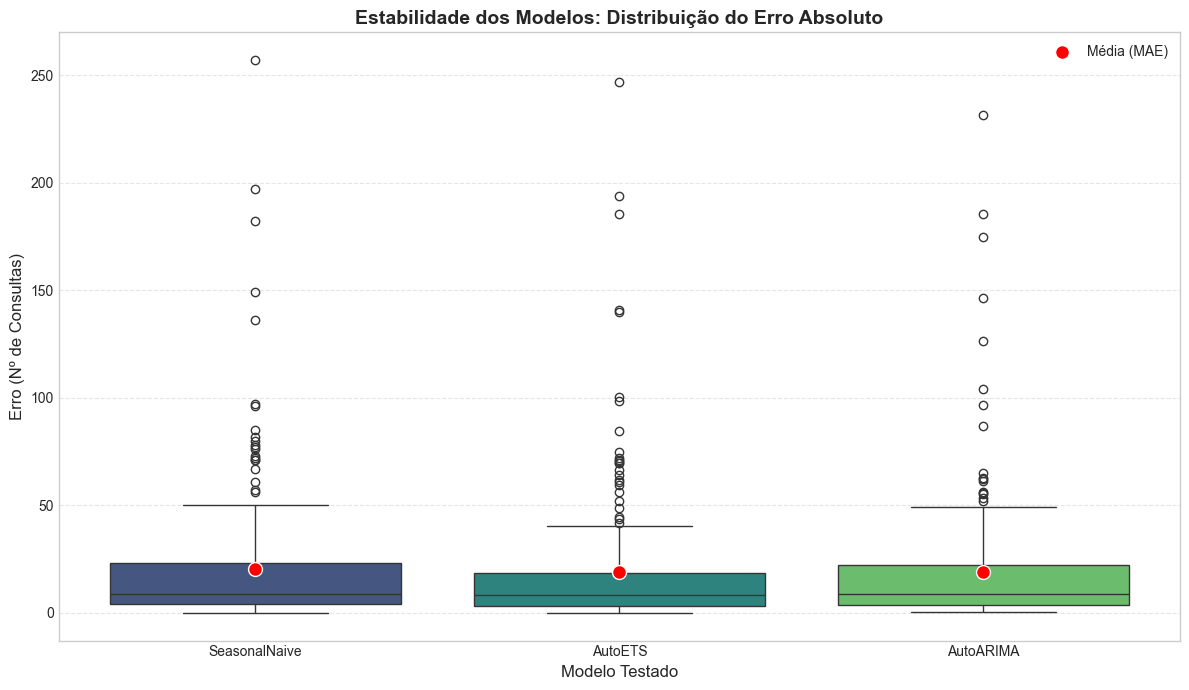


 VALORES DE REFERÊNCIA (MÉDIA vs MEDIANA):
               MAE (Média)  Mediana  Desvio Padrão
Modelo                                            
AutoARIMA            18.98     8.67          30.30
AutoETS              19.04     8.24          32.42
SeasonalNaive        20.47     9.00          33.45


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("AVALIAÇÃO VISUAL: DISTRIBUIÇÃO DOS ERROS (BOX-PLOT)")

# PREPARAR OS DADOS
try:
    df_erros = pd.DataFrame()
    
    # Identificar colunas que são Modelos (excluindo colunas de sistema e exógenas)
    cols_ignorar = ['ds', 'cutoff', 'y', 'unique_id', 'Feriado']
    cols_modelos = [c for c in cv_results_exo.columns if c not in cols_ignorar]
    
    print(f"Modelos em comparação: {cols_modelos}")

    for m in cols_modelos:
        # Calcular erro absoluto (Diferença entre Real e Previsão)
        erros = (cv_results_exo['y'] - cv_results_exo[m]).abs()
        
        # Adicionar à tabela acumulada
        temp = pd.DataFrame({
            'Modelo': m,
            'Erro Absoluto': erros
        })
        df_erros = pd.concat([df_erros, temp], ignore_index=True)

    print("Dados processados com sucesso.")

except NameError:
    print("   ERRO CRÍTICO: A tabela 'cv_results_exo' não existe.")
    raise

# GRÁFICO
plt.figure(figsize=(12, 7))

# Criar Boxplot
# showfliers=False esconde os "outliers" extremos para o gráfico ficar mais limpo
sns.boxplot(x='Modelo', y='Erro Absoluto', data=df_erros, palette="viridis", showfliers=True)

# DESTAQUES E ESTÉTICA
plt.title('Estabilidade dos Modelos: Distribuição do Erro Absoluto', fontsize=14, fontweight='bold')
plt.ylabel('Erro (Nº de Consultas)', fontsize=12)
plt.xlabel('Modelo Testado', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# ADICIONAR AS MÉDIAS (PONTOS VERMELHOS)
medias = df_erros.groupby('Modelo')['Erro Absoluto'].mean()
locs, labels = plt.xticks()

# Garantir que a ordem dos pontos bate certo com a ordem das caixas
modelos_ordenados = [label.get_text() for label in labels]
valores_media = [medias[m] for m in modelos_ordenados]

plt.scatter(locs, valores_media, color='red', s=100, zorder=5, label='Média (MAE)', edgecolors='white')
plt.legend()

plt.tight_layout()
plt.show()

# IMPRIMIR VALORES PARA O RELATÓRIO
print("\n VALORES DE REFERÊNCIA (MÉDIA vs MEDIANA):")
resumo = df_erros.groupby('Modelo')['Erro Absoluto'].agg(['mean', 'median', 'std']).rename(columns={'mean': 'MAE (Média)', 'median': 'Mediana', 'std': 'Desvio Padrão'})
print(resumo.round(2))

Modelo AutoARIMA treinado (com Feriados incluídos).


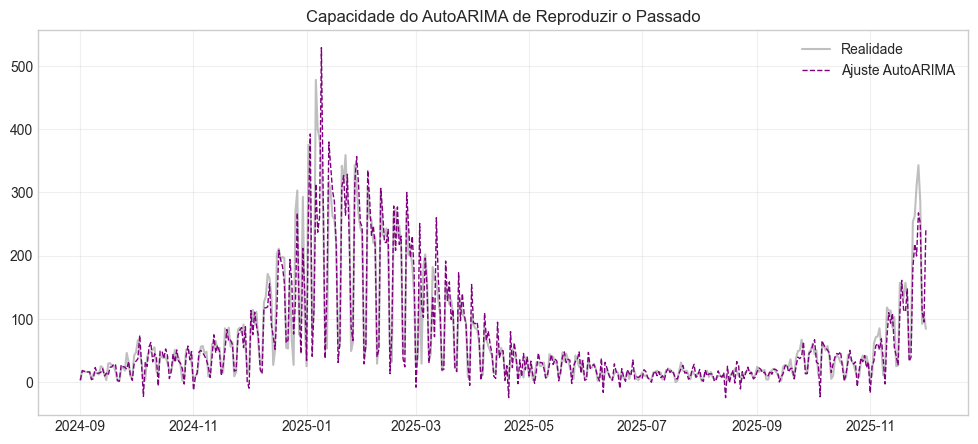

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from statsforecast.models import AutoARIMA
from statsforecast import StatsForecast

# DEFINIR O MODELO AUTOARIMA
model_arima = AutoARIMA(season_length=7, alias='Previsao_Final')

# TREINAR 
# O StatsForecast deteta automaticamente a coluna 'Feriado' no df_treino_final
sf_final = StatsForecast(models=[model_arima], freq='D', n_jobs=-1)
sf_final.fit(df_treino_final)

print("Modelo AutoARIMA treinado (com Feriados incluídos).")

# Precisamos de criar 1 dia de futuro com a coluna Feriado para o .forecast funcionar
last_date = df_treino_final['ds'].max()
future_date = last_date + pd.Timedelta(days=1)
pt_holidays = holidays.PT()

# Verificar se esse dia futuro é feriado 
eh_feriado = 1 if (future_date in pt_holidays) or \
                  ('Carnival' in pt_holidays.get(future_date, "")) or \
                  (future_date.month == 12 and future_date.day in [24, 31]) else 0

# Criar o DataFrame auxiliar
future_df_diag = pd.DataFrame({
    'ds': [future_date],
    'unique_id': [df_treino_final['unique_id'].iloc[0]],
    'Feriado': [eh_feriado] 
})

# FORÇAR CÁLCULO DOS VALORES AJUSTADOS
_ = sf_final.forecast(
    df=df_treino_final, 
    h=1, 
    X_df=future_df_diag, 
    fitted=True
)

# EXTRAIR VALORES
df_diagnostico = sf_final.forecast_fitted_values()

# CALCULAR O ERRO (Real - Estimado)
df_diagnostico['Residuos'] = df_diagnostico['y'] - df_diagnostico['Previsao_Final']

# 7. GRÁFICO DE VERIFICAÇÃO
plt.figure(figsize=(12, 5))
plt.plot(df_diagnostico['ds'], df_diagnostico['y'], label='Realidade', color='gray', alpha=0.5)
plt.plot(df_diagnostico['ds'], df_diagnostico['Previsao_Final'], label='Ajuste AutoARIMA', color='#800080', linestyle='--', linewidth=1) 
plt.title('Capacidade do AutoARIMA de Reproduzir o Passado')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Previsões Objetivo

### 4.1 Melhor Modelo

In [75]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
import pandas as pd

# Instanciar o Modelo Vencedor
# Motivo da escolha: Menor erro absoluto (MAE) na validação cruzada.
# Configuração: O algoritmo otimiza automaticamente os parâmetros (p,d,q):
#   - p: Ordem Auto-Regressiva (Lags passados)
#   - d: Diferenciação (para tornar a série estacionária)
#   - q: Média Móvel (Erros passados)
#   - Inclui Sazonalidade (SARIMA) e Variáveis Exógenas (Feriados) se disponíveis.
modelo_final = AutoARIMA(season_length=7, alias='AutoARIMA')

# Preparar o Motor de Previsão
sf_final = StatsForecast(
    models=[modelo_final],
    freq='D',   # Frequência Diária
    n_jobs=-1   
)

# Treinar o Modelo 
print(f"A treinar o modelo final com dados de {df_treino_final['ds'].min().date()} até {df_treino_final['ds'].max().date()}...")

sf_final.fit(df_treino_final)

print(f"    MODELO TREINADO COM SUCESSO:")
print(f"   Algoritmo:        AutoARIMA (Com suporte a Exógenas)")
print(f"   Justificativa:    Menor MAE nos testes e capacidade de usar calendário (Feriados).")
print(f"   Sazonalidade:     Semanal (season_length=7)")
print(f"   Período de Treino:{df_treino_final['ds'].min().date()} a {df_treino_final['ds'].max().date()}")
print(f"   Total Observações:{len(df_treino_final)} dias")
print(f"   Variáveis Extra:  {df_treino_final.columns.drop(['ds', 'unique_id', 'y']).tolist()}") 
print(f"   Estado:           Pronto para prever.")


A treinar o modelo final com dados de 2024-09-01 até 2025-12-01...
    MODELO TREINADO COM SUCESSO:
   Algoritmo:        AutoARIMA (Com suporte a Exógenas)
   Justificativa:    Menor MAE nos testes e capacidade de usar calendário (Feriados).
   Sazonalidade:     Semanal (season_length=7)
   Período de Treino:2024-09-01 a 2025-12-01
   Total Observações:457 dias
   Variáveis Extra:  ['Feriado']
   Estado:           Pronto para prever.


### 4.2 Análise dos Resíduos

In [76]:
import pandas as pd
import holidays

print("A calcular valores ajustados (Fitted Values) para AutoARIMA...")


# PREPARAÇÃO DO 'X_df' 
last_date = df_treino_final['ds'].max()
future_date = last_date + pd.Timedelta(days=1)
pt_holidays = holidays.PT()

# Calcular se o dia futuro é feriado 
eh_feriado = 1 if (future_date in pt_holidays) or \
                  ('Carnival' in pt_holidays.get(future_date, "")) or \
                  (future_date.month == 12 and future_date.day in [24, 31]) else 0

# Criar DataFrame auxiliar
future_df_aux = pd.DataFrame({
    'ds': [future_date],
    'unique_id': [df_treino_final['unique_id'].iloc[0]],
    'Feriado': [eh_feriado] 
})


# EXTRAÇÃO DOS DADOS


# Passamos o X_df para o modelo não dar erro
_ = sf_final.forecast(
    df=df_treino_final, 
    h=1, 
    X_df=future_df_aux, 
    fitted=True
)

# Recuperar a tabela interna com os valores ajustados
df_diagnostico = sf_final.forecast_fitted_values()


# CÁLCULO DOS RESÍDUOS
df_diagnostico['Residuos'] = df_diagnostico['y'] - df_diagnostico['AutoARIMA']

# Limpeza de NaNs
residuos_limpos = df_diagnostico['Residuos'].dropna()

print(f"   Extraídos {len(residuos_limpos)} dias de resíduos para análise.")
print(f"   Média preliminar do erro (Viés): {residuos_limpos.mean():.4f}")

# Ver as primeiras linhas para confirmar
print("\nPrimeiras 5 linhas do diagnóstico:")
print(df_diagnostico[['ds', 'y', 'AutoARIMA', 'Residuos']].head())

A calcular valores ajustados (Fitted Values) para AutoARIMA...
   Extraídos 457 dias de resíduos para análise.
   Média preliminar do erro (Viés): 1.0692

Primeiras 5 linhas do diagnóstico:
          ds     y  AutoARIMA  Residuos
0 2024-09-01   3.0      2.997     0.003
1 2024-09-02  18.0     17.982     0.018
2 2024-09-03  17.0     16.983     0.017
3 2024-09-04  16.0     15.984     0.016
4 2024-09-05  16.0     15.984     0.016


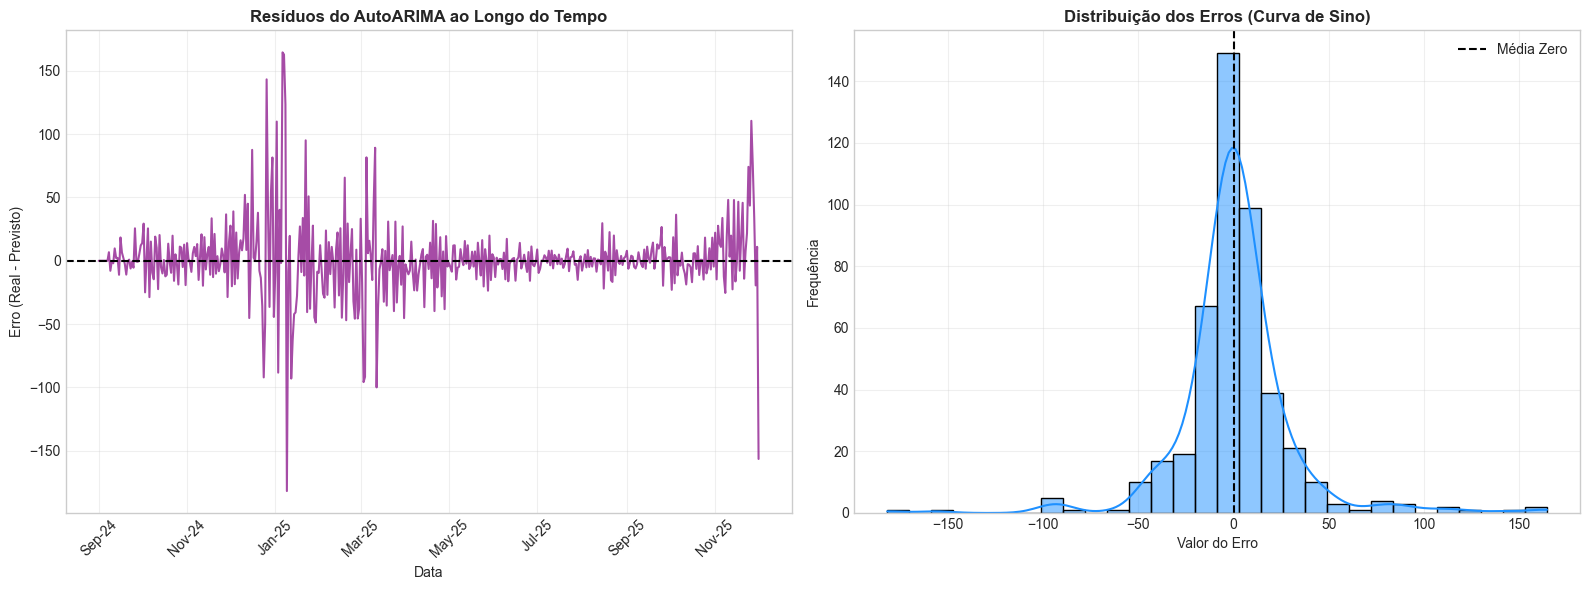

Desvio Padrão dos erros: 30.50


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Preparar os dados para garantir que Datas e Resíduos estão alinhados
if 'df_diagnostico' not in locals():
    raise ValueError("Erro: Corre primeiro a célula anterior para gerar o 'df_diagnostico'")

plot_data = df_diagnostico[['ds', 'Residuos']].dropna()

# Configuração
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GRÁFICO 1: Resíduos no Tempo (Teste de Estabilidade) 
axes[0].plot(plot_data['ds'], plot_data['Residuos'], color='#800080', alpha=0.7) 
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero Ideal')

axes[0].set_title('Resíduos do AutoARIMA ao Longo do Tempo', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Erro (Real - Previsto)')
axes[0].set_xlabel('Data')
axes[0].grid(True, alpha=0.3)

# Formatar o Eixo X 
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2)) 
axes[0].tick_params(axis='x', rotation=45)


# GRÁFICO 2: Histograma (Teste de Distribuição Normal) 
sns.histplot(plot_data['Residuos'], kde=True, ax=axes[1], color='#1E90FF', bins=30) 
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5, label='Média Zero')

axes[1].set_title('Distribuição dos Erros (Curva de Sino)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Valor do Erro')
axes[1].set_ylabel('Frequência')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Desvio Padrão dos erros: {plot_data['Residuos'].std():.2f}")



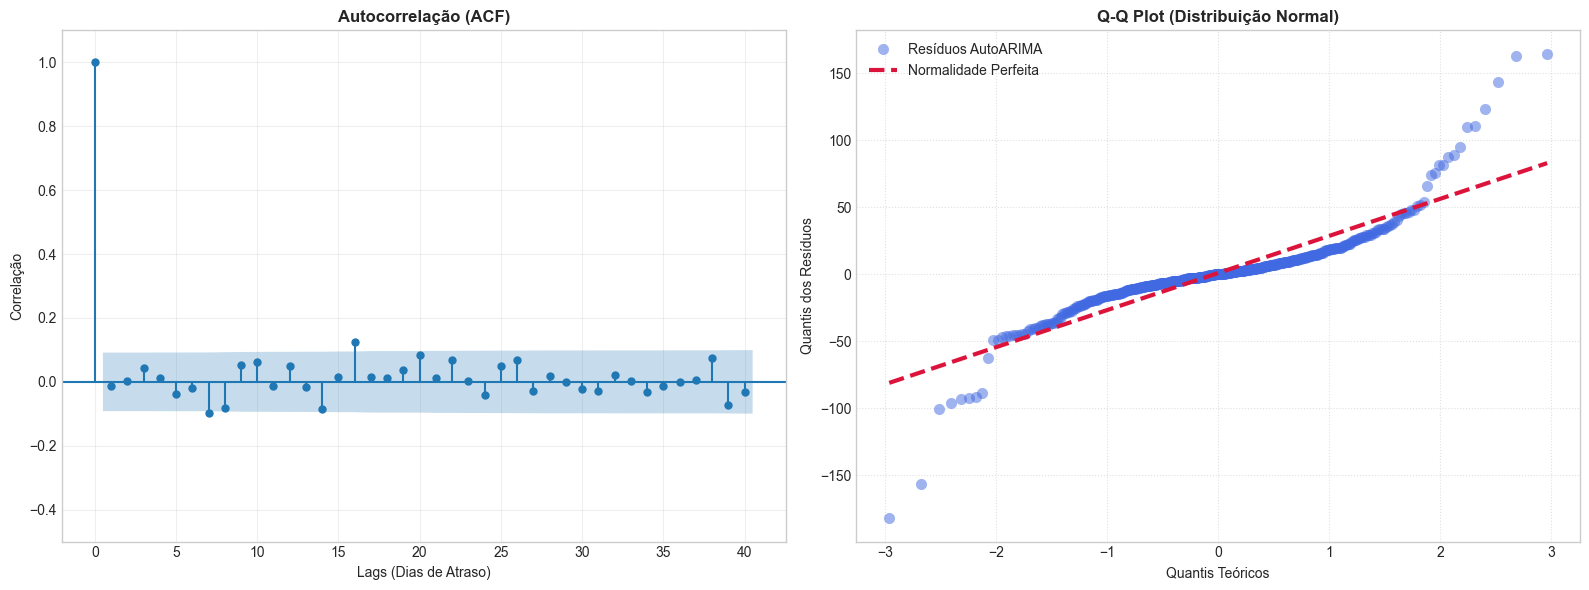

In [82]:
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats
import matplotlib.pyplot as plt

# Verificação de segurança
if 'residuos_limpos' not in locals():
    raise ValueError("Erro: A variável 'residuos_limpos' não existe.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GRÁFICO 3: Autocorrelação (ACF) 
# Fundamental para o ARIMA: Se houver picos fora da sombra azul, 
plot_acf(residuos_limpos, ax=axes[0], lags=40, title=None)

axes[0].set_title('Autocorrelação (ACF)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lags (Dias de Atraso)')
axes[0].set_ylabel('Correlação')
axes[0].set_ylim(-0.5, 1.1)
axes[0].grid(True, alpha=0.3)


# GRÁFICO 4: Q-Q Plot (Normalidade) 
# Compara os erros com uma distribuição normal perfeita
stats.probplot(residuos_limpos, dist="norm", plot=axes[1])

# Personalizar 
pontos = axes[1].get_lines()[0]
pontos.set_markerfacecolor('#4169E1') 
pontos.set_markeredgewidth(0)
pontos.set_markersize(8)
pontos.set_alpha(0.5)
pontos.set_label('Resíduos AutoARIMA') 

# Personalizar Linha 
linha = axes[1].get_lines()[1]
linha.set_color('#DC143C')
linha.set_linewidth(3)
linha.set_linestyle('--')
linha.set_label('Normalidade Perfeita')

axes[1].set_title('Q-Q Plot (Distribuição Normal)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quantis Teóricos')
axes[1].set_ylabel('Quantis dos Resíduos')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [83]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

print("DIAGNÓSTICO ESTATÍSTICO DOS RESÍDUOS")

# Verificação de segurança
if 'residuos_limpos' not in locals():
    raise ValueError("Erro: A variável 'residuos_limpos' não existe")

# TESTE DE NORMALIDADE (Shapiro-Wilk)

stat_sh, p_sh = stats.shapiro(residuos_limpos)
curtose = stats.kurtosis(residuos_limpos)

print(f"\n1. NORMALIDADE (Shapiro-Wilk)")
print(f"   Estatística: {stat_sh:.4f}")
print(f"   p-value:     {p_sh:.4e}")
print(f"   Curtose:     {curtose:.2f}")

if p_sh > 0.05:
    print("      Hipótese Nula aceite: Os resíduos seguem uma distribuição Normal.")
else:
    print("      Hipótese Nula rejeitada: Os resíduos NÃO são normais.")
    print("      (Isto é esperado em dados hospitalares devido a outliers/picos extremos).")


# TESTE DE INDEPENDÊNCIA (Ljung-Box)
# Verifica se o ARIMA capturou toda a informação temporal ("White Noise")
lags_teste = [7, 14] # Verificar repetições semanais e quinzenais
lb_test = acorr_ljungbox(residuos_limpos, lags=lags_teste, return_df=True)

print(f"\n2. AUTOCORRELAÇÃO RESIDUAL (Ljung-Box)")
print(lb_test[['lb_stat', 'lb_pvalue']].round(4))

p_val_7 = lb_test.loc[7, 'lb_pvalue']

if p_val_7 > 0.05:
    print("      O AutoARIMA capturou bem a sazonalidade semanal (p > 0.05).")
    print("      Os resíduos comportam-se como ruído branco (aleatórios).")
else:
    print("      Existe alguma correlação residual no dia 7.")
    print("      O modelo pode ter deixado passar algum padrão semanal subtil.")

# VIÉS (Média Zero)
# Verifica se o modelo tem tendência a prever sistematicamente acima ou abaixo
t_stat, p_vies = stats.ttest_1samp(residuos_limpos, 0)

print(f"\n3. VIÉS DE PREVISÃO (T-Test)")
print(f"   Média do Erro: {residuos_limpos.mean():.4f}")
print(f"   p-value:       {p_vies:.4f}")

if p_vies > 0.05:
    print("      O modelo NÃO é enviesado (a média dos erros é estatisticamente zero).")
else:
    print("      O modelo apresenta um ligeiro viés estatístico.")

DIAGNÓSTICO ESTATÍSTICO DOS RESÍDUOS

1. NORMALIDADE (Shapiro-Wilk)
   Estatística: 0.8216
   p-value:     3.6627e-22
   Curtose:     9.96
      Hipótese Nula rejeitada: Os resíduos NÃO são normais.
      (Isto é esperado em dados hospitalares devido a outliers/picos extremos).

2. AUTOCORRELAÇÃO RESIDUAL (Ljung-Box)
    lb_stat  lb_pvalue
7    6.1993     0.5167
14  17.1598     0.2478
      O AutoARIMA capturou bem a sazonalidade semanal (p > 0.05).
      Os resíduos comportam-se como ruído branco (aleatórios).

3. VIÉS DE PREVISÃO (T-Test)
   Média do Erro: 1.0692
   p-value:       0.4540
      O modelo NÃO é enviesado (a média dos erros é estatisticamente zero).


### 4.3 Previsões objetivo (com intervalos de previsão)

In [86]:
import pandas as pd
import holidays

print("PREVISÃO FINAL (AUTOARIMA COM EXÓGENAS)")

# DEFINIR O HORIZONTE
HORIZONTE = 12
NIVEIS = [95] 

# CRIAÇÃO RÁPIDA DO X_df (Para garantir que a variável existe)

last_date = df_treino_final['ds'].max()
datas_futuras = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=HORIZONTE, freq='D')
pt_holidays = holidays.PT()

lista_feriados = []
for data in datas_futuras:
    eh_feriado = 0
    if data in pt_holidays: eh_feriado = 1
    if 'Carnival' in pt_holidays.get(data, ""): eh_feriado = 1
    if data.month == 12 and data.day in [24, 31]: eh_feriado = 1
    lista_feriados.append(eh_feriado)

future_df = pd.DataFrame({
    'ds': datas_futuras,
    'unique_id': df_treino_final['unique_id'].iloc[0],
    'Feriado': lista_feriados
})


# EXECUTAR A PREVISÃO

previsao_obj = sf_final.forecast(
    df=df_treino_final, 
    h=HORIZONTE, 
    X_df=future_df, 
    level=NIVEIS
)

previsao_obj = previsao_obj.reset_index()

# Juntamos a previsão com o future_df para recuperar a coluna 'Feriado'
tabela_completa = pd.merge(previsao_obj, future_df, on=['ds', 'unique_id'], how='left')

print("Previsão calculada com sucesso.")

print(tabela_completa[['ds', 'AutoARIMA', 'Feriado']].head())

PREVISÃO FINAL (AUTOARIMA COM EXÓGENAS)
Previsão calculada com sucesso.
          ds   AutoARIMA  Feriado
0 2025-12-02  161.869797        0
1 2025-12-03  253.184128        0
2 2025-12-04  334.051422        0
3 2025-12-05  252.162430        0
4 2025-12-06  102.801247        0


In [90]:
import pandas as pd

print("ANÁLISE FINAL: SEMANA ALVO (06 a 12 DEZEMBRO)")

# DEFINIR A SEMANA QUE QUEREMOS ANALISAR
DATA_INICIO = '2025-12-06'
DATA_FIM = '2025-12-12'

# FILTRAR A TABELA GERAL 
mask = (tabela_completa['ds'] >= DATA_INICIO) & (tabela_completa['ds'] <= DATA_FIM)
df_semana_alvo = tabela_completa[mask].copy()

# BUSCAR OS DADOS REAIS 
dados_reais = df_trabalho[['ds', 'y']].copy()

# Juntar tudo: Previsão + Realidade
df_final = pd.merge(df_semana_alvo, dados_reais, on='ds', how='left')

# LIMPEZA E FORMATAÇÃO 
col_lo = [c for c in df_final.columns if 'lo-95' in c][0]
col_hi = [c for c in df_final.columns if 'hi-95' in c][0]

df_apresentacao = df_final.rename(columns={
    'ds': 'Data',
    'y': 'Real',
    'AutoARIMA': 'Previsão',
    col_lo: 'Min (95%)',
    col_hi: 'Max (95%)',
    'Feriado': 'É Feriado?'
})

# Adicionar Dia da Semana
dias_pt = {
    'Monday': 'Segunda', 'Tuesday': 'Terça', 'Wednesday': 'Quarta', 
    'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
df_apresentacao['Dia da Semana'] = df_apresentacao['Data'].dt.day_name().map(dias_pt)

# Reordenar colunas
cols_finais = ['Data', 'Dia da Semana', 'É Feriado?', 'Real', 'Previsão', 'Min (95%)', 'Max (95%)']
df_apresentacao = df_apresentacao[cols_finais].round(1)

# 5. MOSTRAR A TABELA FINAL
print("\n RESULTADO FINAL DA SEMANA:")
print(df_apresentacao.to_string(index=False))

# 6. CALCULAR O ERRO FINAL (MAE) DESTA SEMANA
mae_final = (df_apresentacao['Real'] - df_apresentacao['Previsão']).abs().mean()
print(f"\n ERRO MÉDIO ABSOLUTO (MAE) NA SEMANA ALVO: {mae_final:.2f} episódios")

ANÁLISE FINAL: SEMANA ALVO (06 a 12 DEZEMBRO)

 RESULTADO FINAL DA SEMANA:
      Data Dia da Semana  É Feriado?  Real   Previsão  Min (95%)  Max (95%)
2025-12-06        Sábado           0   201 102.800003  22.500000 183.199997
2025-12-07       Domingo           0   192  87.699997   7.300000 168.100006
2025-12-08       Segunda           1   201  92.400002  11.700000 173.100006
2025-12-09         Terça           0   919 154.399994  55.299999 253.500000
2025-12-10        Quarta           0   907 255.699997 145.199997 366.299988
2025-12-11        Quinta           0   291 333.000000 220.500000 445.600006
2025-12-12         Sexta           0   741 251.199997 138.399994 364.000000

 ERRO MÉDIO ABSOLUTO (MAE) NA SEMANA ALVO: 322.69 episódios


GRÁFICO FINAL: VISUALIZAÇÃO DA SEMANA ALVO


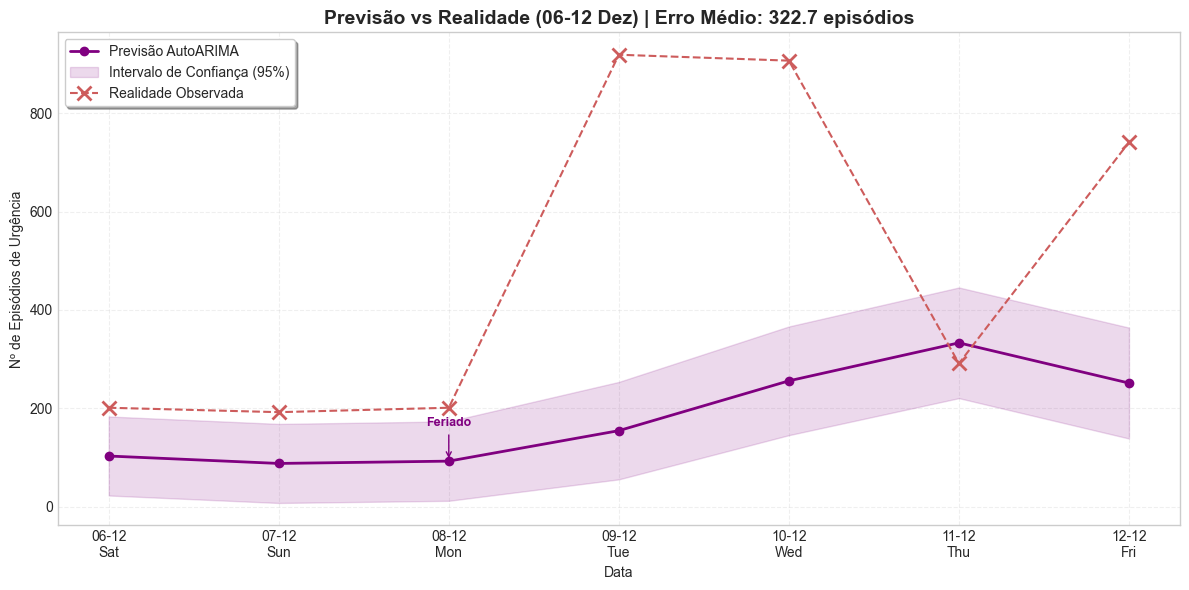

In [93]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("GRÁFICO FINAL: VISUALIZAÇÃO DA SEMANA ALVO")

plt.figure(figsize=(12, 6))

# PREVISÃO (AutoARIMA)
plt.plot(df_apresentacao['Data'], df_apresentacao['Previsão'], 
         label='Previsão AutoARIMA', 
         color='#800080', marker='o', linewidth=2, zorder=2) 

# INTERVALO DE CONFIANÇA
plt.fill_between(df_apresentacao['Data'], 
                 df_apresentacao['Min (95%)'], 
                 df_apresentacao['Max (95%)'], 
                 color="#800080", alpha=0.15, label='Intervalo de Confiança (95%)')

# DADOS REAIS
plt.plot(df_apresentacao['Data'], df_apresentacao['Real'], 
         label='Realidade Observada', 
         color='#CD5C5C', marker='x', linestyle='--', 
         markersize=10, markeredgewidth=2, zorder=3) 

# ANOTAÇÃO AUTOMÁTICA DE FERIADOS
for i, row in df_apresentacao.iterrows():
    if row['É Feriado?'] == 1:
        plt.annotate('Feriado', 
                     xy=(row['Data'], row['Previsão']), 
                     xytext=(0, 25), textcoords='offset points',
                     ha='center', fontsize=9, color='#800080', fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color='#800080'))

# ESTÉTICA E FORMATAÇÃO
plt.title(f'Previsão vs Realidade (06-12 Dez) | Erro Médio: {mae_final:.1f} episódios', 
          fontsize=14, fontweight='bold')

plt.ylabel('Nº de Episódios de Urgência')
plt.xlabel('Data')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='upper left', frameon=True, shadow=True)

# Formatar eixo X 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m\n%a')) 
plt.gca().xaxis.set_major_locator(mdates.DayLocator())

plt.tight_layout()
plt.show()